## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    roc_curve
)

## Load Dataset

In [2]:
df = pd.read_csv('Covid_patients.csv')
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [3]:
# Print dataset information
print("Dataset Information:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575

## Prepare the Data

In [4]:
# Replace specific missing value indicators
replace_dict = {97: np.nan, 98: np.nan, 99: np.nan}
df_cleaned = df.replace(replace_dict)

df_cleaned.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,NaN,1.0,65.0,2.0,2.0,...,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3,NaN
1,2,1,2,1,03/06/2020,NaN,1.0,72.0,NaN,2.0,...,2.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,5,NaN
2,2,1,2,2,09/06/2020,1.0,2.0,55.0,NaN,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0
3,2,1,1,1,12/06/2020,NaN,2.0,53.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,7,NaN
4,2,1,2,1,21/06/2020,NaN,2.0,68.0,NaN,1.0,...,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3,NaN


Missing Value Percentages:
USMER                    0.00
MEDICAL_UNIT             0.00
SEX                      0.00
PATIENT_TYPE             0.00
DATE_DIED                0.00
INTUBED                 81.62
PNEUMONIA                1.53
AGE                      0.03
PREGNANT                50.28
DIABETES                 0.32
COPD                     0.29
ASTHMA                   0.28
INMSUPR                  0.32
HIPERTENSION             0.30
OTHER_DISEASE            0.48
CARDIOVASCULAR           0.29
OBESITY                  0.29
RENAL_CHRONIC            0.29
TOBACCO                  0.31
CLASIFFICATION_FINAL     0.00
ICU                     81.64


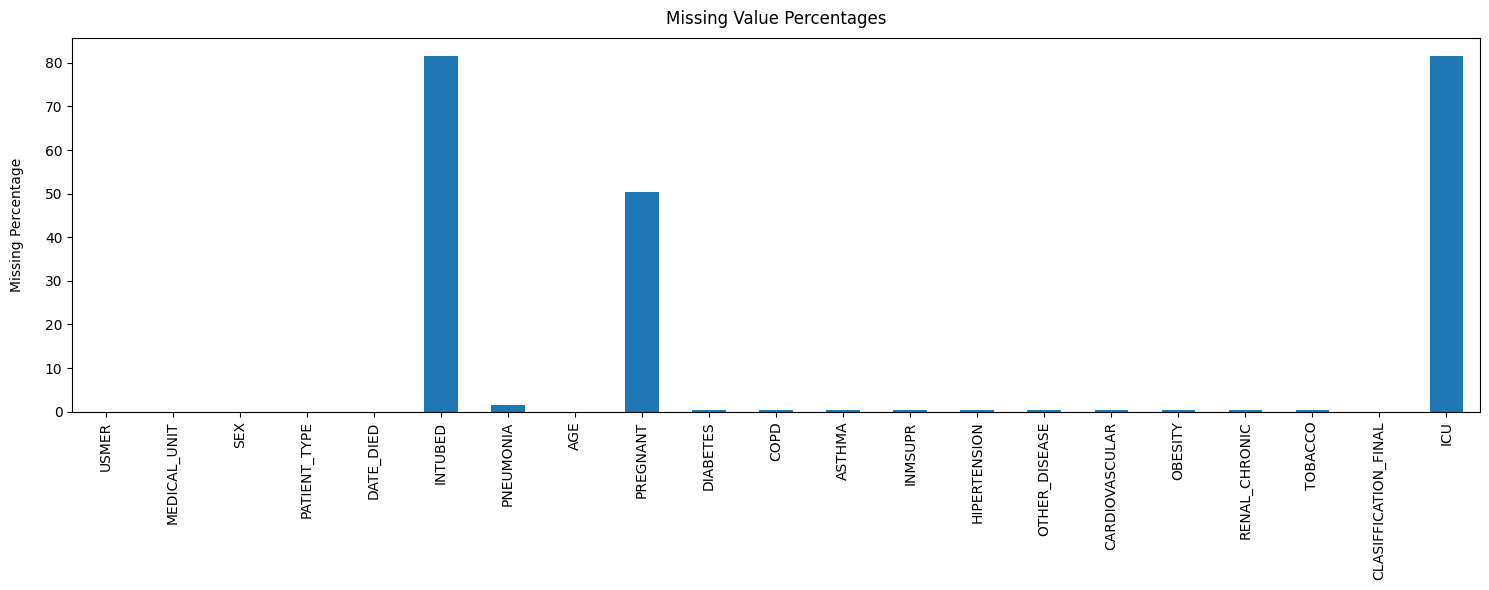

In [5]:
# Detailed missing value analysis
missing_percentage = df_cleaned.isnull().mean() * 100
print("Missing Value Percentages:\n" + missing_percentage.round(2).to_string())

plt.figure(figsize=(15, 6))
missing_percentage.plot(kind='bar')
plt.title('Missing Value Percentages', pad = 10)
plt.xlabel('')
plt.ylabel('Missing Percentage', labelpad = 15)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 🤖 Classification Models 🤖

We are dealing with three binary classification problems:
- **Survival Prediction:** Predict DIED (0 = survived, 1 = died).
- **Intubation Prediction:** Predict INTUBED (1 = yes, 2 = no → convert to 0/1).
- **ICU Admission Prediction:** Predict ICU (1 = yes, 2 = no → convert to 0/1).

Each problem is a supervised learning task where we classify patients based on their medical attributes.

### Prepare datasets for different classification problems

In [6]:
# Create target variables (y)
df_cleaned['DIED'] = (df_cleaned['DATE_DIED'] != '9999-99-99').astype(int)
df_cleaned['INTUBED_BINARY'] = (df_cleaned['INTUBED'] == 1).astype(int)
df_cleaned['ICU_BINARY'] = (df_cleaned['ICU'] == 1).astype(int)

In [7]:
# Features selection (X)
features = [
    'USMER', 'MEDICAL_UNIT', 'SEX', 'AGE', 'PNEUMONIA', 'DIABETES', 
    'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'CARDIOVASCULAR', 
    'RENAL_CHRONIC', 'OTHER_DISEASE', 'OBESITY', 'TOBACCO', 'PATIENT_TYPE'
]

# Feature selection (Remove features with >10% missing)
def select_features(features, max_missing_pct=10):
    return [f for f in features if missing_percentage[f] <= max_missing_pct]

In [8]:
# 1. Survival Prediction
features_died = select_features(features)
X_died = df_cleaned[features_died]
y_died = df_cleaned['DIED']

# 2. Intubation Prediction
features_intubed = select_features(features)
X_intubed = df_cleaned[features_intubed]
y_intubed = df_cleaned['INTUBED_BINARY']

# 3. ICU Admission Prediction
features_icu = select_features(features)
X_icu = df_cleaned[features_icu]
y_icu = df_cleaned['ICU_BINARY']

### Preprocessing pipeline

In [9]:
def create_preprocessor(features):
    numeric_features = ['AGE']
    categorical_features = [f for f in features if f != 'AGE']

    preprocessor = ColumnTransformer([
        # Replace Nan with the median/mode and standardize the data (with mean = 0, standard deviation = 1)
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), categorical_features)
    ])
    return preprocessor

### Model Training and Evaluation

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True)
}

classification_problems = [
    ('Survival Prediction', X_died, y_died, features_died),
    ('Intubation Prediction', X_intubed, y_intubed, features_intubed),
    ('ICU Admission Prediction', X_icu, y_icu, features_icu)
]

In [ ]:
results = {}
for problem, X, y, features in classification_problems:
    print(f"\n{problem}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Create preprocessing pipeline
    preprocessor = create_preprocessor(features)

    # Store model results
    results[problem] = {}

    # Evaluate each model
    for model_name, model in models.items():
        # Create pipeline
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

        # Fit and predict
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # Calculate metrics
        model_results = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_prob)
        }

        # Store results
        results[problem][model_name] = model_results

        # Print classification report
        print(f"\n{model_name} Classification Report:")
        print(classification_report(y_test, y_pred))


Survival Prediction

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96    194327
           1       0.57      0.39      0.47     15388

    accuracy                           0.93    209715
   macro avg       0.76      0.69      0.71    209715
weighted avg       0.92      0.93      0.93    209715


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    194327
           1       0.51      0.39      0.44     15388

    accuracy                           0.93    209715
   macro avg       0.73      0.68      0.70    209715
weighted avg       0.92      0.93      0.92    209715


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    194327
           1       0.52      0.41      0.46     15388

    accuracy                           0.

**🔍 Insights 🔍**

The reports are for survival prediction, where:
- 0 = Survived
- 1 = Died

The dataset is highly imbalanced (194,327 survivors vs. 15,388 deaths), leading to:
- All models have a high accuracy (~93%).
- The models fail to detect deaths well (only ~39-41% recall).

### Visualize Results

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
plt.figure(figsize=(15, 10))

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 columns for the 5 metrics
    
    data = []
    labels = []
    
    for problem, model_results in results.items():
        for model_name, result in model_results.items():
            data.append(result[metric])
            labels.append(f"{problem}\n{model_name}")
    
    plt.bar(labels, data)
    plt.title(metric.capitalize())
    plt.xticks(rotation=45, ha='right')  
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.suptitle("Model Performance Comparison", fontsize=16)
plt.show()

# 🤖 Regression Models 🤖